# Módulo 1. Inducción

# Milena Fernanda Rivera Hernández

# Aprendizaje supervisado (segunda parte)
Impoartido por:

Dr. Mario Graff Guerrero  
**Dra. Daniela Moctezuma Ochoa**  dmoctezuma@centrogeo.edu.mx  
Dr. Eric S. Téllez Avila  
Dr. Luis Guillermo Ruiz Velázquez

# Es hora de poner en práctica lo aprendido, para ello deberán realizar el siguiente ejercicio:

Con los datos proporcionados, o con cualquier conjunto de datos que uds prefieran, la unica condición es que tenga una variable dependiente.

En caso de no contar con una base de datos, puede seleccionar una base de datos en el siguiente link:
   # https://archive.ics.uci.edu/datasets

### Van a cargar los datos y deberán crear un modelo de clasificación con, al menos, los algoritmos vistos ahora (pueden incorporar más si es que los vieron en otros módulos /clases. Al final usando CompStats, deberán compararlos y decir cuál es el mejor.

In [132]:
# NOTA IMPORTANTE: La redaccion de la elaboracion de cada algoritmo son propiedad
# intelectual de la Dra. Daniela Moctezuma Ochoa por lo que su reproduccion
# es meramente para implementar lo aprendido, no se pretende atribuir ningun
# tipo de credito. (Es decir, si copie textualmente lo que se compartio con el
# curso pero modifique brevemente para ajustar al dataset del vino)

import sklearn as sk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [133]:
# Usando los datos usados en clase
# Mas ABAJO uso el dataset de la CALIDAD DEL VINO

# NOTA:'heart.csv.txt' lo subi en files de Colab en la sesion que use
# por lo que si se desea replicar en otra sesion se debe subir aparte.

df = pd.read_csv("heart.csv.txt")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [134]:
# Separacion de variables categoricas de continuas
categorical_val = []
continous_val = []
for column in df.columns:
  if len(df[column].unique()) <= 10:
    categorical_val.append(column)
  else:
    continous_val.append(column)

categorical_val.remove('target')
dataset = pd.get_dummies(df, columns = categorical_val, dtype=int)

In [135]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,37,130,250,187,3.5,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
2,41,130,204,172,1.4,1,1,0,0,1,...,1,1,0,0,0,0,0,0,1,0
3,56,120,236,178,0.8,1,0,1,0,1,...,1,1,0,0,0,0,0,0,1,0
4,57,120,354,163,0.6,1,1,0,1,0,...,1,1,0,0,0,0,0,0,1,0


In [136]:
# Estandarizamos
from sklearn.preprocessing import StandardScaler
# Estandarizar las características eliminando la media y escalando a la varianza a la unidad
s_sc = StandardScaler()
col_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[col_to_scale] = s_sc.fit_transform(dataset[col_to_scale])

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
X = df.drop('target', axis=1)
y = df.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Arboles de desicion

In [138]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=3,
max_features=None, max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=7, min_samples_split=2)
tree.fit(X_train, y_train)
p = tree.predict(X_test)
print("Accuracy", accuracy_score(p, y_test))
print("F1 score", f1_score(p, y_test))
print("Precision", precision_score(p, y_test))
print("Recall", recall_score(p, y_test))

Accuracy 0.7692307692307693
F1 score 0.7835051546391752
Precision 0.76
Recall 0.8085106382978723


# Random Forest

In [139]:
from sklearn.ensemble import RandomForestClassifier
rand_forest = RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
max_depth=3, max_features=0.3, max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=10, min_samples_split=2,
min_weight_fraction_leaf=0.0, n_estimators=1000)
rand_forest.fit(X_train, y_train)
p_rf = rand_forest.predict(X_test)
print("Accuracy", accuracy_score(p_rf, y_test))
print("F1 score", f1_score(p_rf, y_test))
print("Precision", precision_score(p_rf, y_test))
print("Recall", recall_score(p_rf, y_test))

Accuracy 0.8241758241758241
F1 score 0.8431372549019608
Precision 0.86
Recall 0.8269230769230769


#SVM


In [140]:
from sklearn.svm import SVC
svm_model = SVC(C=2, cache_size=200, class_weight=None, coef0=0.0,
decision_function_shape='ovr', degree=3, gamma=0.001,
kernel='rbf', max_iter=-1)
svm_model.fit(X_train, y_train)
p_svm = svm_model.predict(X_test)
print("Accuracy", accuracy_score(p_svm, y_test))
print("F1 score", f1_score(p_svm, y_test))
print("Precision", precision_score(p_svm, y_test))
print("Recall", recall_score(p_svm, y_test))

Accuracy 0.6813186813186813
F1 score 0.7128712871287128
Precision 0.72
Recall 0.7058823529411765


#KNN

Maximum KNN score on the test data: 0.6923076923076923
Accuracy 0.6923076923076923
F1 score 0.7142857142857143
Precision 0.7
Recall 0.7291666666666666


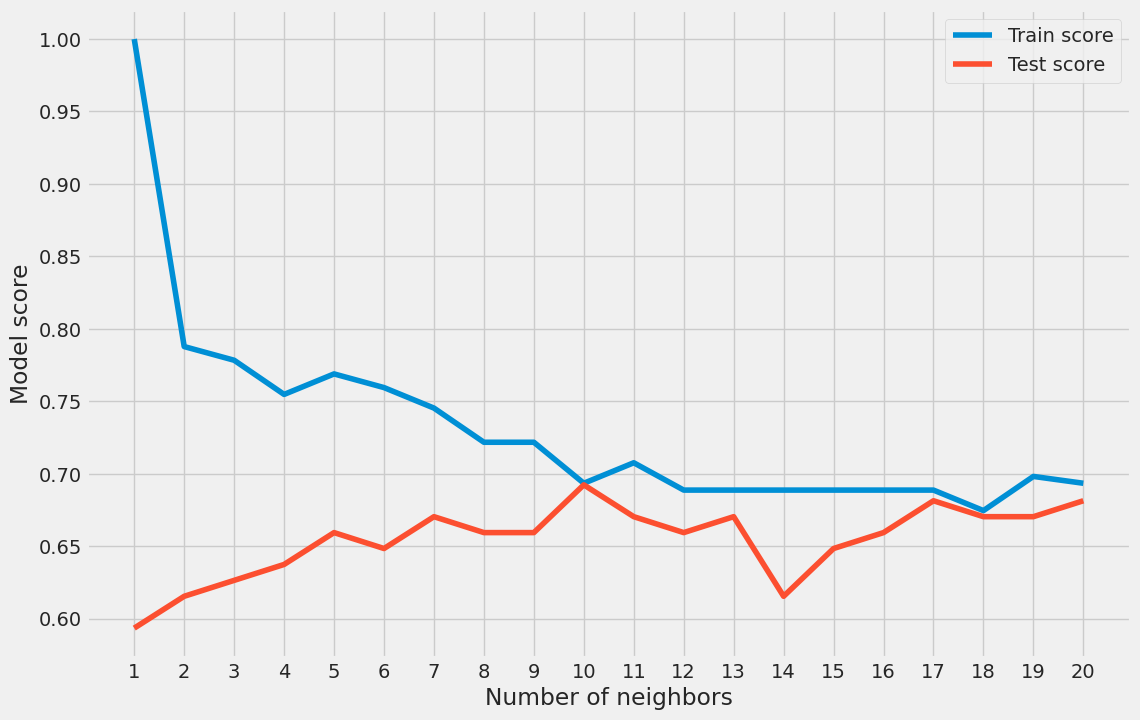

In [141]:
from sklearn.neighbors import KNeighborsClassifier
train_score = []
test_score = []
neighbors = range(1, 21)
for k in neighbors:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  train_score.append(accuracy_score(y_train, model.predict(X_train)))
  test_score.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(12, 8))
plt.plot(neighbors, train_score, label="Train score")
plt.plot(neighbors, test_score, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()
print("Maximum KNN score on the test data:", max(test_score))


knn_classifier = KNeighborsClassifier(n_neighbors=10)
knn_classifier.fit(X_train, y_train)
p_knn = knn_classifier.predict(X_test)
print("Accuracy", accuracy_score(p_knn, y_test))
print("F1 score", f1_score(p_knn, y_test))
print("Precision", precision_score(p_knn, y_test))
print("Recall", recall_score(p_knn, y_test))

#Naive Bayes

In [142]:
from sklearn.naive_bayes import GaussianNB
GBmodel = GaussianNB()
GBmodel.fit(X_train, y_train)
p_GB = GBmodel.predict(X_test)
print("Accuracy", accuracy_score(p_GB, y_test))
print("F1 score", f1_score(p_GB, y_test))
print("Precision", precision_score(p_GB, y_test))
print("Recall", recall_score(p_GB, y_test))

Accuracy 0.8351648351648352
F1 score 0.8421052631578947
Precision 0.8
Recall 0.8888888888888888


# GridSearch

In [143]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# Seleccionamos el tipo de clasificador, en este caso RandomForest.
clf_optimo = RandomForestClassifier()
# Parámetros del clasificador
parameters = {'n_estimators': [10, 20, 30, 50],
'max_features': [0.2, 0.3,0.5],
'criterion': ['entropy', 'gini'],
'max_depth': [2, 3, 5, 10],
'min_samples_split': [2, 3, 5],
'min_samples_leaf': [1,5,8]
}
# n_estimators es el número de árboles en el bosque
# Número de features a considerar en cada split. log2(n_f)
# Tipo de evaluación utilizada para comparar las combinaciones hechas
# por el algoritmo.
acc_scorer = make_scorer(accuracy_score)
# se ejecuta la busqueda Grid
grid_obj = GridSearchCV(clf_optimo, parameters, scoring=acc_scorer)
grid_obj = grid_obj.fit(X_train, y_train)
# Se establece para el clasificador la mejor combinación de parámetros
clf_optimo = grid_obj.best_estimator_
# Se ajusta el mejor algoritmo a los datos
clf_optimo.fit(X_train, y_train)
predictions = clf_optimo.predict(X_test)
# se imprime el accuracy
print(accuracy_score(y_test, predictions))

0.8241758241758241


#Comparacion con CompStats

In [144]:
pip install CompStats

In [145]:
from CompStats import performance, plot_performance
from CompStats import difference, plot_difference
from CompStats import all_differences, difference_p_value
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import f1_score
import pandas as pd

In [146]:
concentrado = pd.DataFrame()

In [147]:
concentrado['Decision Tree'] = p
concentrado['Random Forest'] = p_rf
concentrado['SVM'] = p_svm
concentrado['KNN'] = p_knn
concentrado['NaiveB'] = p_GB

In [148]:
concentrado['y'] = list(y_test)
concentrado

,Decision Tree,Random Forest,SVM,KNN,NaiveB,y
0,0,0,0,0,0,0
1,1,1,1,0,1,0
2,1,1,1,0,1,1
3,0,0,1,1,0,0
4,1,1,0,0,1,1
...,...,...,...,...,...,...
86,0,0,0,0,0,0
87,1,1,1,1,1,1
88,0,0,1,0,1,1
89,0,0,0,0,0,1


In [149]:
score = lambda y, hy: f1_score(y, hy, average='weighted')

In [150]:
 perf = performance(concentrado, score=score, num_samples=1000)

100%|██████████| 6/6 [00:42<00:00,  7.11s/it]


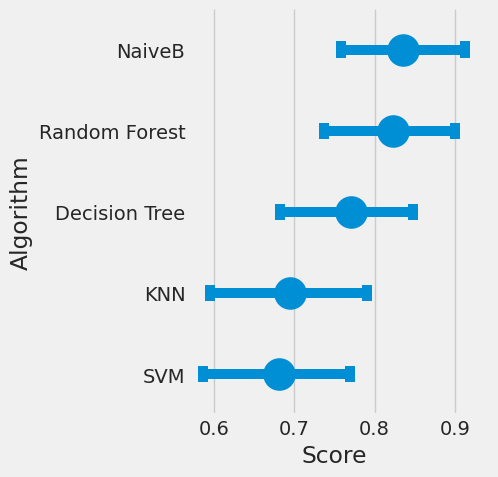

In [151]:
face_grid = plot_performance(perf)

In [152]:
diff = difference(perf)
diff.info

{'best': 'NaiveB'}

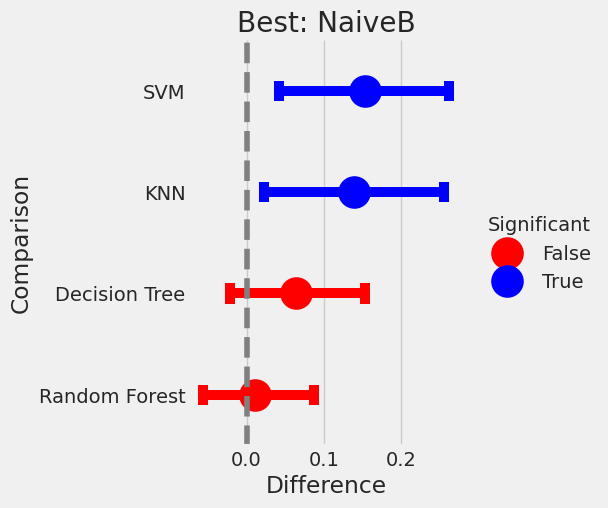

In [153]:
face_grid_diff = plot_difference(diff)

In [154]:
# comparacion entre todos
all_diff = all_differences(perf)

In [155]:
 p_values = difference_p_value(all_diff)

In [156]:
p_values

{'NaiveB - Random Forest': np.float64(0.365),
 'NaiveB - Decision Tree': np.float64(0.067),
 'NaiveB - KNN': np.float64(0.011),
 'NaiveB - SVM': np.float64(0.002),
 'Random Forest - Decision Tree': np.float64(0.051),
 'Random Forest - KNN': np.float64(0.011),
 'Random Forest - SVM': np.float64(0.002),
 'Decision Tree - KNN': np.float64(0.103),
 'Decision Tree - SVM': np.float64(0.061),
 'KNN - SVM': np.float64(0.365)}

# **Usando otro data set**
## Dataset de la calidad del vino

In [157]:
# NOTA:'wine.csv.data' lo subi en files de Colab en la sesion que use
# por lo que si se desea replicar en otra sesion se debe subir aparte.

# En la entrega de la practica adjunto el csv que use.


df2 = pd.read_csv("wine.csv.data")
df2.head()

,class,alcohol,malicacid,ash,alcalinity_of_ash,magnesium,total_phenols,flavonoids,nonflavanoid_phenols,proanthocyanins,color_density,hue,0D280_0D315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [158]:
# Separacion de variables categoricas de continuas
categorical_val = []
continous_val = []
for column in df2.columns:
  if len(df2[column].unique()) <= 10:
    categorical_val.append(column)
  else:
    continous_val.append(column)

categorical_val.remove('class') # class=target
dataset2 = pd.get_dummies(df2, columns = categorical_val, dtype=int)

In [159]:
dataset2.head()

,class,alcohol,malicacid,ash,alcalinity_of_ash,magnesium,total_phenols,flavonoids,nonflavanoid_phenols,proanthocyanins,color_density,hue,0D280_0D315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [160]:
# estandarizar
from sklearn.preprocessing import StandardScaler
# Estandarizar las características eliminando la media y escalando a la varianza a la unidad
s_sc = StandardScaler()
col_to_scale = ['alcohol', 'malicacid', 'ash', 'alcalinity_of_ash',
    'magnesium', 'total_phenols', 'flavonoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_density', 'hue',
    '0D280_0D315_of_diluted_wines', 'proline']
dataset2[col_to_scale] = s_sc.fit_transform(dataset2[col_to_scale])

In [161]:
 dataset2.head()

,class,alcohol,malicacid,ash,alcalinity_of_ash,magnesium,total_phenols,flavonoids,nonflavanoid_phenols,proanthocyanins,color_density,hue,0D280_0D315_of_diluted_wines,proline
0,1,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,1,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,1,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [162]:
# Dividiendo los datos en entrenamiento y prueba

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
X = df2.drop('class', axis=1)
y = df2['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Árboles de desición

In [163]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=3,
max_features=None, max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=7, min_samples_split=2)
tree.fit(X_train, y_train)
p = tree.predict(X_test)
print("Accuracy", accuracy_score(p, y_test))
print("F1 score", f1_score(p, y_test, average='macro')) # es multiclase
print("Precision", precision_score(p, y_test,average='macro'))
print("Recall", recall_score(p, y_test,average='macro'))

Accuracy 0.8518518518518519
F1 score 0.8510989010989011
Precision 0.8458646616541353
Recall 0.861111111111111


# Random Forest

In [164]:
from sklearn.ensemble import RandomForestClassifier
rand_forest = RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
max_depth=3, max_features=0.3, max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=10, min_samples_split=2,
min_weight_fraction_leaf=0.0, n_estimators=1000)
rand_forest.fit(X_train, y_train)
p_rf = rand_forest.predict(X_test)
print("Accuracy", accuracy_score(p_rf, y_test))
print("F1 score", f1_score(p_rf, y_test,average='macro'))
print("Precision", precision_score(p_rf, y_test,average='macro'))
print("Recall", recall_score(p_rf, y_test,average='macro'))

Accuracy 0.9629629629629629
F1 score 0.9632920719127616
Precision 0.9682539682539683
Recall 0.9611111111111111


#SVM

In [165]:
from sklearn.svm import SVC
svm_model = SVC(C=2, cache_size=200, class_weight=None, coef0=0.0,
decision_function_shape='ovr', degree=3, gamma=0.001,
kernel='rbf', max_iter=-1)
svm_model.fit(X_train, y_train)
p_svm = svm_model.predict(X_test)
print("Accuracy", accuracy_score(p_svm, y_test))
print("F1 score", f1_score(p_svm, y_test,average='macro'))
print("Precision", precision_score(p_svm, y_test,average='macro'))
print("Recall", recall_score(p_svm, y_test,average='macro'))

Accuracy 0.7407407407407407
F1 score 0.7260560990364894
Precision 0.7268170426065163
Recall 0.7260233918128655


#KNN

In [166]:
from sklearn.neighbors import KNeighborsClassifier
train_score = []
test_score = []
neighbors = range(1, 21)
for k in neighbors:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  train_score.append(accuracy_score(y_train, model.predict(X_train)))
  test_score.append(accuracy_score(y_test, model.predict(X_test)))

Maximum KNN score on the test data: 0.7962962962962963


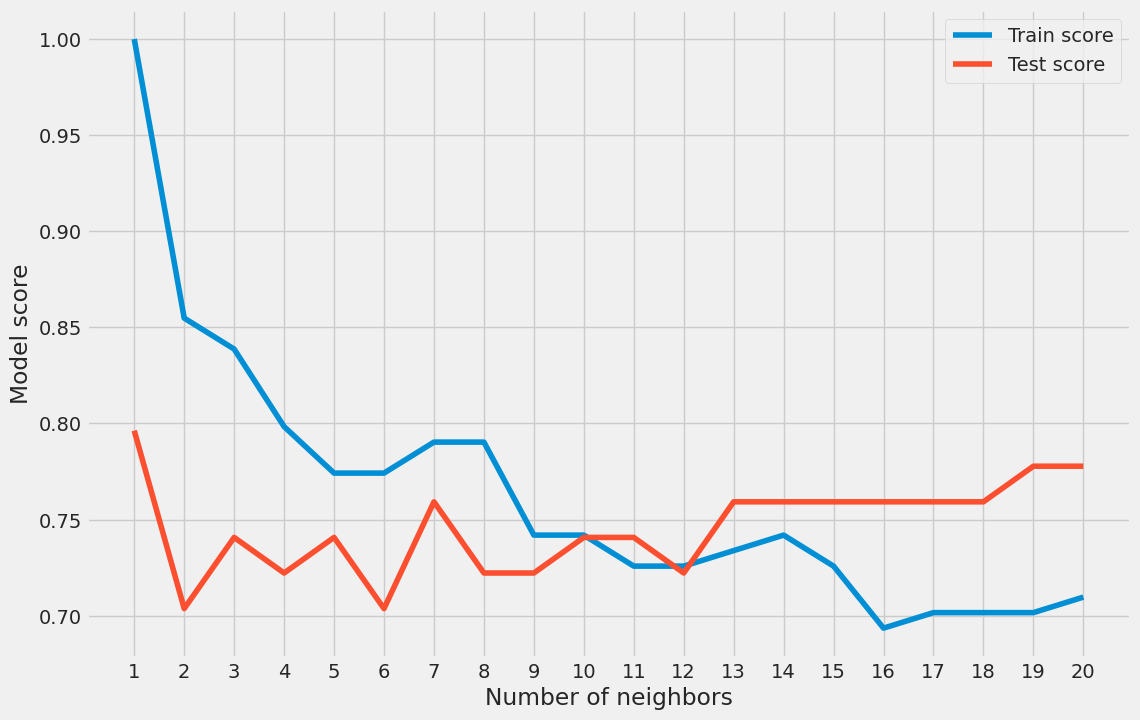

In [167]:
plt.figure(figsize=(12, 8))
plt.plot(neighbors, train_score, label="Train score")
plt.plot(neighbors, test_score, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()
print("Maximum KNN score on the test data:", max(test_score))

In [168]:
knn_classifier = KNeighborsClassifier(n_neighbors=10)
knn_classifier.fit(X_train, y_train)
p_knn = knn_classifier.predict(X_test)
print("Accuracy", accuracy_score(p_knn, y_test))
print("F1 score", f1_score(p_knn, y_test,average='macro'))
print("Precision", precision_score(p_knn, y_test,average='macro'))
print("Recall", recall_score(p_knn, y_test,average='macro'))

Accuracy 0.7407407407407407
F1 score 0.7137430470763805
Precision 0.7222222222222222
Recall 0.7141087575870184


#Naive Bayes

In [169]:
from sklearn.naive_bayes import GaussianNB
GBmodel = GaussianNB()
GBmodel.fit(X_train, y_train)
p_GB = GBmodel.predict(X_test)
print("Accuracy", accuracy_score(p_GB, y_test))
print("F1 score", f1_score(p_GB, y_test,average='macro'))
print("Precision", precision_score(p_GB, y_test,average='macro'))
print("Recall", recall_score(p_GB, y_test,average='macro'))

Accuracy 1.0
F1 score 1.0
Precision 1.0
Recall 1.0


#GridSearch

In [170]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# Seleccionamos el tipo de clasificador, en este caso RandomForest.
clf_optimo = RandomForestClassifier()
# Parámetros del clasificador
parameters = {'n_estimators': [10, 20, 30, 50],
'max_features': [0.2, 0.3,0.5],
'criterion': ['entropy', 'gini'],
'max_depth': [2, 3, 5, 10],
'min_samples_split': [2, 3, 5],
'min_samples_leaf': [1,5,8]
}
# n_estimators es el número de árboles en el bosque
# Número de features a considerar en cada split. log2(n_f)
# Tipo de evaluación utilizada para comparar las combinaciones hechas
# por el algoritmo.
acc_scorer = make_scorer(accuracy_score)
# se ejecuta la busqueda Grid
grid_obj = GridSearchCV(clf_optimo, parameters, scoring=acc_scorer)
grid_obj = grid_obj.fit(X_train, y_train)
# Se establece para el clasificador la mejor combinación de parámetros
clf_optimo = grid_obj.best_estimator_
# Se ajusta el mejor algoritmo a los datos
clf_optimo.fit(X_train, y_train)
predictions = clf_optimo.predict(X_test)
# se imprime el accuracy
print(accuracy_score(y_test, predictions))

0.9444444444444444


# Comparacion con CompStats

In [171]:
pip install CompStats

In [172]:
import sklearn

In [173]:
from CompStats import performance, plot_performance
from CompStats import difference, plot_difference
from CompStats import all_differences, difference_p_value
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import f1_score
import pandas as pd

In [174]:
concentrado2 = pd.DataFrame()

In [175]:
concentrado2['Decision Tree'] = p
concentrado2['Random Forest'] = p_rf
concentrado2['SVM'] = p_svm
concentrado2['KNN'] = p_knn
concentrado2['NaiveB'] = p_GB

In [176]:
concentrado2['y'] = list(y_test)
concentrado2

,Decision Tree,Random Forest,SVM,KNN,NaiveB,y
0,1,1,3,1,1,1
1,1,1,1,1,1,1
2,1,3,3,2,3,3
3,1,1,1,1,1,1
4,2,2,2,2,2,2
5,1,1,1,1,1,1
6,2,2,2,3,2,2
7,3,3,3,1,3,3
8,2,2,3,3,2,2
9,1,3,1,1,3,3


In [177]:
score = lambda y, hy: f1_score(y, hy, average='weighted')

In [178]:
perf = performance(concentrado2, score=score, num_samples=1000)

100%|██████████| 6/6 [00:31<00:00,  5.23s/it]


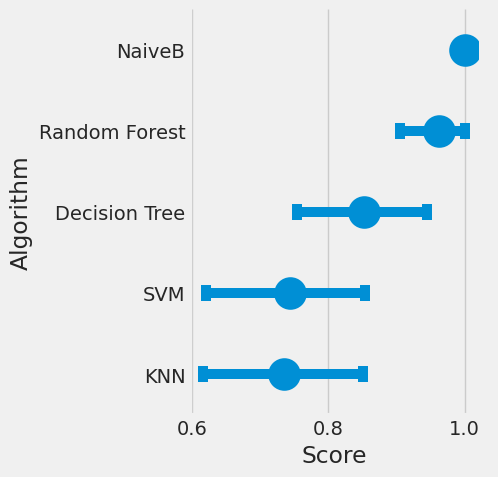

In [179]:
face_grid = plot_performance(perf)

In [180]:
diff = difference(perf)

In [181]:
diff.info

{'best': 'NaiveB'}

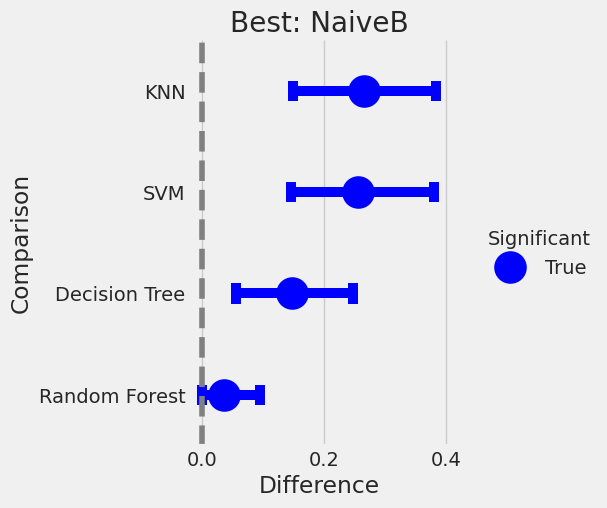

In [182]:
face_grid_diff = plot_difference(diff)

In [183]:
all_diff = all_differences(perf)

In [184]:
p_values = difference_p_value(all_diff)

In [185]:
p_values

{'NaiveB - Random Forest': np.float64(0.127),
 'NaiveB - Decision Tree': np.float64(0.004),
 'NaiveB - SVM': np.float64(0.0),
 'NaiveB - KNN': np.float64(0.0),
 'Random Forest - Decision Tree': np.float64(0.008),
 'Random Forest - SVM': np.float64(0.0),
 'Random Forest - KNN': np.float64(0.0),
 'Decision Tree - SVM': np.float64(0.079),
 'Decision Tree - KNN': np.float64(0.058),
 'SVM - KNN': np.float64(0.434)}

En general, podemos concluir que NaiveBayes se muestra, en general, superior a los demás algoritmos.